In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import os

In [32]:
dataset ="archive (2)"

print(os.listdir(dataset))

['no', 'yes']


In [33]:
dataAug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
train_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
val_data = dataAug.flow_from_directory(
    dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)
print(train_data.class_indices)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
{'no': 0, 'yes': 1}


In [34]:
model = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3), padding = 'same', kernel_initializer= 'he_normal'),
    keras.layers.MaxPooling2D(2,2),
    
    keras.layers.Conv2D(64,(3,3),activation='relu', padding = 'same', kernel_initializer= 'he_normal'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,(3,3),activation='relu', padding = 'same', kernel_initializer= 'he_normal'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1,activation='sigmoid')
])
model.summary()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 513ms/step - accuracy: 0.4975 - loss: 5.0139 - val_accuracy: 0.7600 - val_loss: 0.7655
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - accuracy: 0.7389 - loss: 0.6435 - val_accuracy: 0.7200 - val_loss: 0.5673
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - accuracy: 0.7734 - loss: 0.5531 - val_accuracy: 0.7600 - val_loss: 0.5505
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - accuracy: 0.7833 - loss: 0.5955 - val_accuracy: 0.6800 - val_loss: 0.5879
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - accuracy: 0.7734 - loss: 0.5227 - val_accuracy: 0.7600 - val_loss: 0.6081
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 415ms/step - accuracy: 0.7635 - loss: 0.5189 - val_accuracy: 0.7200 - val_loss: 0.5228
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.7783 - loss: 0.5126 - val_accuracy: 0.7600 - val_loss: 0.4825
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step - accuracy: 0.7537 - loss: 0.5195 - val_accuracy: 0.6600 - val_loss:

In [37]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


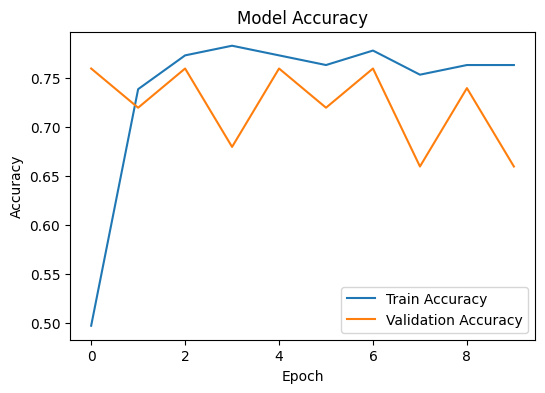

In [38]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

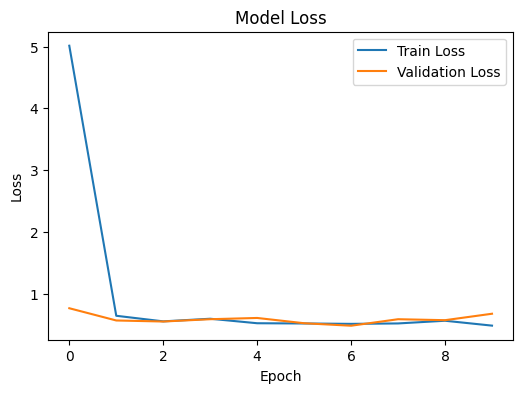

In [39]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


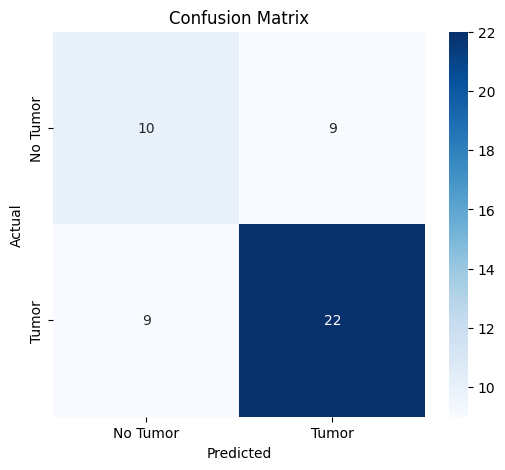

In [40]:

predictions = model.predict(val_data)
y_pred = (predictions > 0.5).astype(int)
y_true = val_data.classes

cm = confusion_matrix(y_true,y_pred)



plt.figure(figsize=(6,5))
sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['No Tumor','Tumor'],
yticklabels=['No Tumor','Tumor'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [41]:
print(classification_report(
y_true,
y_pred,
labels=[0,1], 
target_names=['No Tumor','Tumor']
))

              precision    recall  f1-score   support

    No Tumor       0.53      0.53      0.53        19
       Tumor       0.71      0.71      0.71        31

    accuracy                           0.64        50
   macro avg       0.62      0.62      0.62        50
weighted avg       0.64      0.64      0.64        50



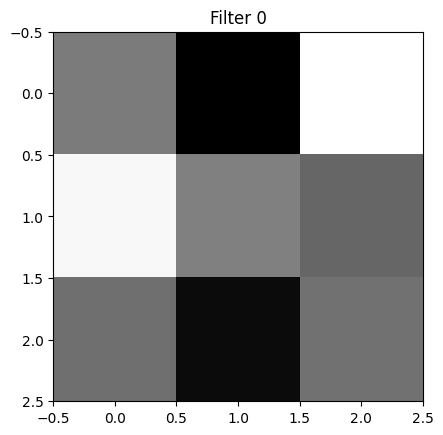

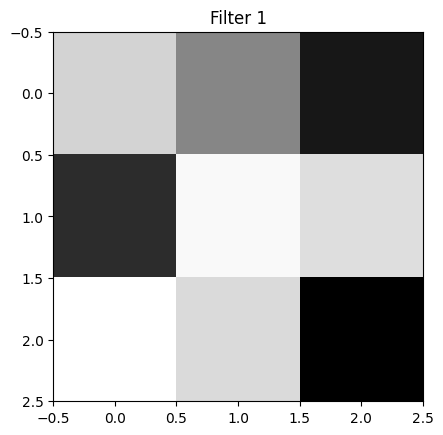

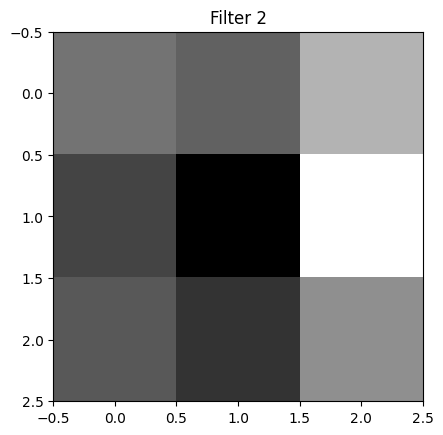

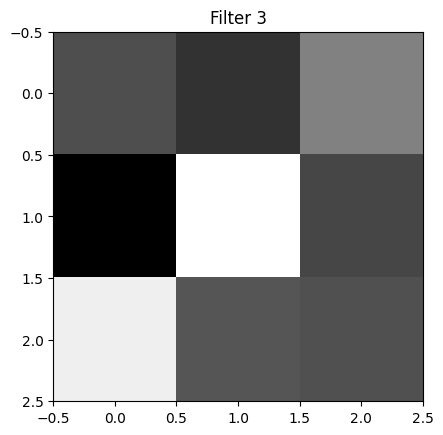

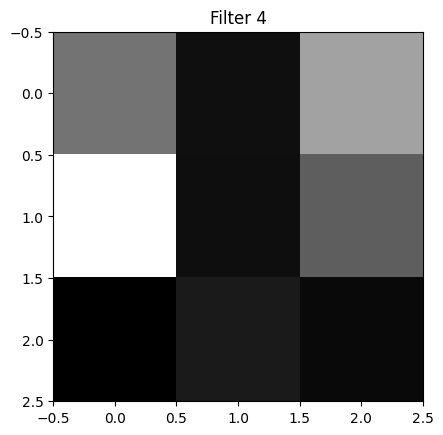

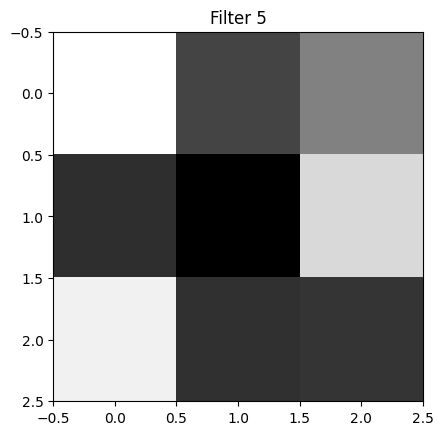

In [42]:
filters, biases = model.layers[0].get_weights()

for i in range(6):
    f = filters[:,:,:,i]
    plt.imshow(f[:,:,0], cmap="gray")
    plt.title("Filter "+str(i))
    plt.show()

**CAM**

In [43]:
img_path = "archive (2)/yes/Y1.jpg"

img = keras.preprocessing.image.load_img(img_path,target_size=(224,224))
img_array = keras.preprocessing.image.img_to_array(img)/255
img_array = np.expand_dims(img_array,axis=0)

**GRAD CAM**

In [44]:
_=model.predict(img_array)
last_conv_layer = model.layers[4]

grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.outputs]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[0][:,0]

grads = tape.gradient(loss, conv_outputs)
# Average gradients
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

# Weighted sum
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
# Normalize
heatmap = np.maximum(heatmap,0)/np.max(heatmap)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_38']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
